In [ ]:
import sys
import os
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from pycgp_finalclass.Config import CGPConfig
from pycgp_finalclass.ES import ES
from pycgp_finalclass.Evaluator import EvaluatorSin, Binary_Classifier, Regressor, MultiClassClassifier
from pycgp_finalclass.Node import Node
from pycgp_finalclass.Mutation import Golden_mutation
from pycgp_finalclass.Function import Func
from pycgp_finalclass.Function_library import *
from pycgp_finalclass.Genome import CGPGenome


In [2]:
def build_funcLib(): #Define the function used
    return [Func(f_sum, 'sum', 2, 0),
            Func(f_aminus, 'aminus', 2, 0),
            Func(f_mult, 'mult', 2, 0),
            Func(f_exp, 'exp', 2, 0),
            Func(f_abs, 'abs', 1, 0),
            Func(f_sqrt, 'sqrt', 1, 0),
            Func(f_sqrtxy, 'sqrtxy', 2, 0),
            Func(f_squared, 'squared', 1, 0),
            Func(f_pow, 'pow', 2, 0),
            Func(f_one, 'one', 0, 0),
            Func(f_zero, 'zero', 0, 0),
            Func(f_const, 'const', 0, 1),
            Func(f_inv, 'inv', 1, 0),
            Func(f_gt, 'gt', 2, 0),
            Func(f_asin, 'asin', 1, 0),
            Func(f_acos, 'acos', 1, 0),
            Func(f_atan, 'atan', 1, 0),
            Func(f_sin, 'sin', 1, 0),
            Func(f_min, 'min', 2, 0),
            Func(f_max, 'max', 2, 0),
            Func(f_round, 'round', 1, 0),
            Func(f_floor, 'floor', 1, 0),
            Func(f_ceil, 'ceil', 1, 0)
            ]
functions = build_funcLib()

In [3]:
#In development
""" from scipy.io import arff
import pandas as pd

# Load the .arff file
data, meta = arff.loadarff("datasets/Colon_fixed.arff")

# Convert to pandas DataFrame
df = pd.DataFrame(data)

# If string columns are returned as bytes, decode them
for col in df.select_dtypes([object]).columns:
    df[col] = df[col].str.decode('utf-8')

# Replace "relapse" with 1 and "non-relapse" with 0 in the 'Class' column
df['class'] = df['class'].replace({'Tumor': 1, 'Normal': 0})


from sklearn.preprocessing import MinMaxScaler

# Séparation des features et de la cible
X = df.drop('class', axis=1)  # Features
y = df['class']               # Target

# Conversion des colonnes en float
X = X.astype(float)

# Standardisation avec MinMaxScaler dans l'intervalle [-1, 1]
scaler = MinMaxScaler(feature_range=(-1, 1))
X = scaler.fit_transform(X)

evaluator2 = Binary_Classifier(X, y) """

' from scipy.io import arff\nimport pandas as pd\n\n# Load the .arff file\ndata, meta = arff.loadarff("datasets/Colon_fixed.arff")\n\n# Convert to pandas DataFrame\ndf = pd.DataFrame(data)\n\n# If string columns are returned as bytes, decode them\nfor col in df.select_dtypes([object]).columns:\n    df[col] = df[col].str.decode(\'utf-8\')\n\n# Replace "relapse" with 1 and "non-relapse" with 0 in the \'Class\' column\ndf[\'class\'] = df[\'class\'].replace({\'Tumor\': 1, \'Normal\': 0})\n\n\nfrom sklearn.preprocessing import MinMaxScaler\n\n# Séparation des features et de la cible\nX = df.drop(\'class\', axis=1)  # Features\ny = df[\'class\']               # Target\n\n# Conversion des colonnes en float\nX = X.astype(float)\n\n# Standardisation avec MinMaxScaler dans l\'intervalle [-1, 1]\nscaler = MinMaxScaler(feature_range=(-1, 1))\nX = scaler.fit_transform(X)\n\nevaluator2 = Binary_Classifier(X, y) '

In [4]:




#Initialise config + Evaluator + mutation 
CGP_config = CGPConfig(num_inputs=1, num_nodes=30, num_outputs=1, input_node_chance=0.4, const_min=-1, const_max=1, function_set=functions)
#For evaluatorsin num_inputs = 1

#mutationcgp_proba = Proba_Mutation(CGP_config, number_mutations=10, input_node_mutation_rate=0.2, output_node_mutation_rate=0.1, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1)
mutationcgp_golden = Golden_mutation(CGP_config,input_node_mutation_rate=0.2, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1,output_node_mutation_rate=0.1)

evaluator1 = EvaluatorSin()

#Test purpose
genome_cgp = CGPGenome.create_genome(CGP_config)
active_nodes = genome_cgp.get_active_nodes()
print("Active nodes:", active_nodes)



Active nodes: [<pycgp_finalclass.Node.Node object at 0x00000215ADFC9E50>, <pycgp_finalclass.Node.Node object at 0x00000215ADFC9670>, <pycgp_finalclass.Node.Node object at 0x00000215ADFCA990>]


Starting fitness -1.7248
Early stopping at generation 134 (no improvement for 100 generations).

Best fitness achieved: 0.9995
n1 = max(x0, x0)
n2 = atan(n1)
n3 = asin(n2)
n4 = sqrt(n1)
n5 = aminus(n2, n4)
n6 = aminus(x0, n3)
n7 = max(n2, n1)
n8 = one()
n9 = acos(n2)
n10 = inv(n4)
n11 = squared(n3)
n12 = floor(n10)
n13 = atan(n10)
n14 = const()
n15 = sin(n3)
n16 = exp(n4, n12)
n17 = aminus(n9, x0)
n18 = pow(n4, n2)
n19 = sum(n5, x0)
n20 = round(n15)
n21 = acos(x0)
n22 = max(n4, n20)
n23 = ceil(n2)
n24 = floor(x0)
n25 = gt(n1, n19)
n26 = atan(n15)
n27 = pow(n13, n18)
n28 = round(n25)
n29 = mult(n17, n10)
n30 = mult(x0, x0)
Outputs: n26

Unrolled output expression 0:
atan(sin(asin(atan(max(x0, x0)))))



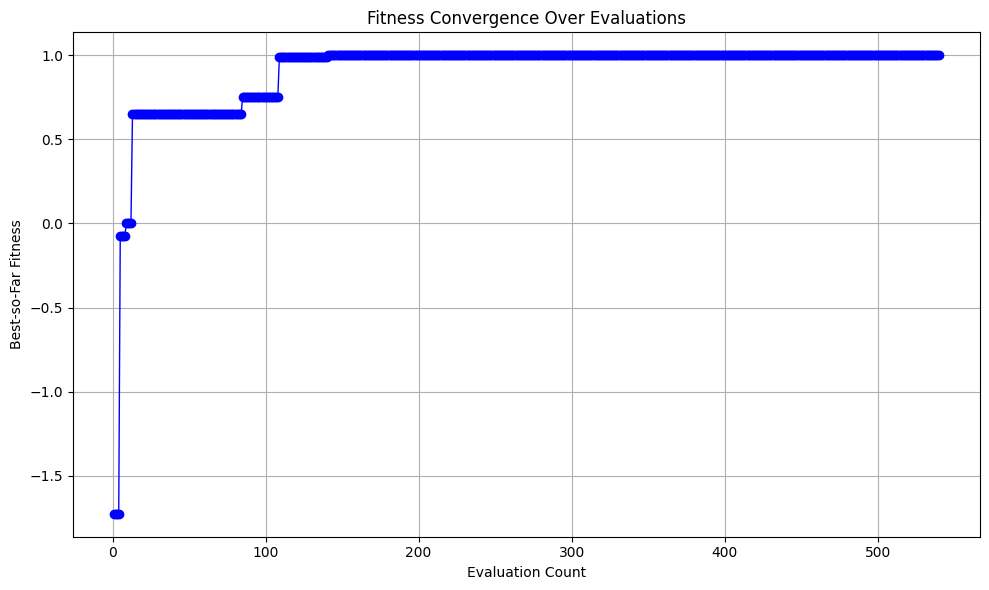

c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\pycgp_finalclass\Genome.py:243: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


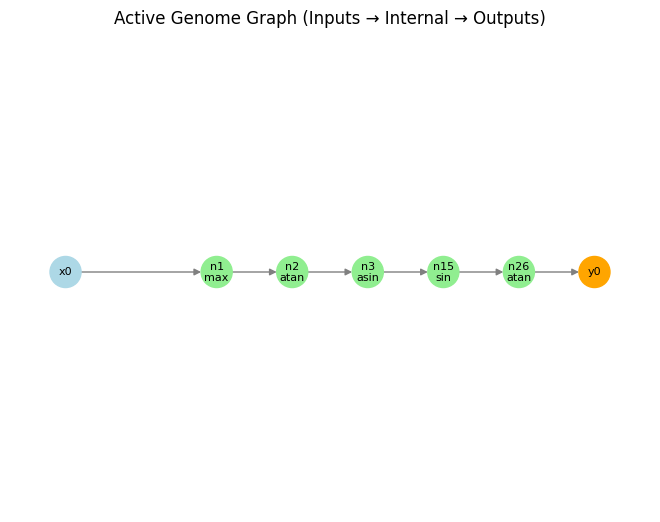

n1 = max(x0, x0)
n2 = atan(n1)
n3 = asin(n2)
n4 = sqrt(n1)
n5 = aminus(n2, n4)
n6 = aminus(x0, n3)
n7 = max(n2, n1)
n8 = one()
n9 = acos(n2)
n10 = inv(n4)
n11 = squared(n3)
n12 = floor(n10)
n13 = atan(n10)
n14 = const()
n15 = sin(n3)
n16 = exp(n4, n12)
n17 = aminus(n9, x0)
n18 = pow(n4, n2)
n19 = sum(n5, x0)
n20 = round(n15)
n21 = acos(x0)
n22 = max(n4, n20)
n23 = ceil(n2)
n24 = floor(x0)
n25 = gt(n1, n19)
n26 = atan(n15)
n27 = pow(n13, n18)
n28 = round(n25)
n29 = mult(n17, n10)
n30 = mult(x0, x0)
Outputs: n26

Unrolled output expression 0:
atan(sin(asin(atan(max(x0, x0)))))



In [ ]:
#Initialise the ES and run the evolution
ES_cgp = ES(evaluator1, lam=4, parent = CGPGenome.create_genome(CGP_config),mutation = mutationcgp_golden)
best_genome = ES_cgp.evolve(n_generations=10000, early_stopping=100)

print(best_genome.to_function_string())


n1 = max(x0, x0)
n2 = atan(n1)
n3 = asin(n2)
n4 = sqrt(n1)
n5 = aminus(n2, n4)
n6 = aminus(x0, n3)
n7 = max(n2, n1)
n8 = one()
n9 = acos(n2)
n10 = inv(n4)
n11 = squared(n3)
n12 = floor(n10)
n13 = atan(n10)
n14 = const()
n15 = sin(n3)
n16 = exp(n4, n12)
n17 = aminus(n9, x0)
n18 = pow(n4, n2)
n19 = sum(n5, x0)
n20 = round(n15)
n21 = acos(x0)
n22 = max(n4, n20)
n23 = ceil(n2)
n24 = floor(x0)
n25 = gt(n1, n19)
n26 = atan(n15)
n27 = pow(n13, n18)
n28 = round(n25)
n29 = mult(n17, n10)
n30 = mult(x0, x0)
Outputs: n26

Unrolled output expression 0:
atan(sin(asin(atan(max(x0, x0)))))



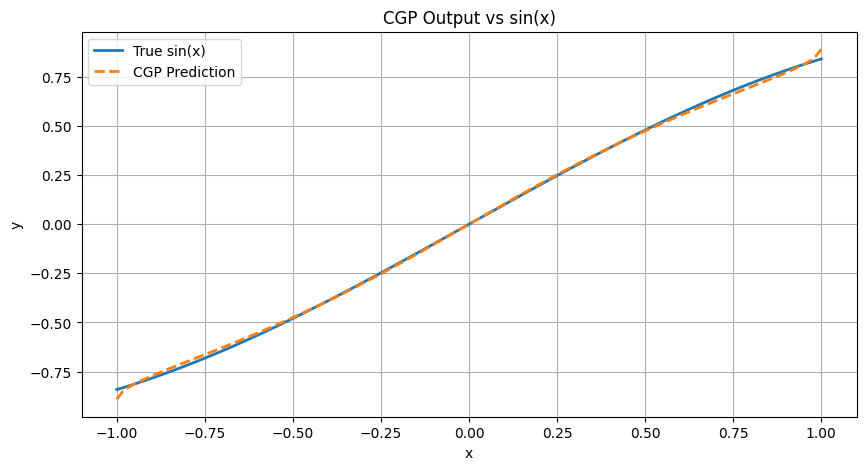

Fitness of best genome: 0.9994764683730581


In [6]:
#See if the output fit the sin function

import matplotlib.pyplot as plt

def plot_sin_vs_prediction(evaluator, genome):
    inputs = evaluator.inputs
    targets = evaluator.targets

    predictions = [genome.get_value([x])[0] for x in inputs]

    plt.figure(figsize=(10, 5))
    plt.plot(inputs, targets, label='True sin(x)', linewidth=2)
    plt.plot(inputs, predictions, label='CGP Prediction', linestyle='--', linewidth=2)
    plt.title('CGP Output vs sin(x)')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()
print(best_genome.to_function_string())
plot_sin_vs_prediction(evaluator1, best_genome)
print(f"Fitness of best genome: {evaluator1.evaluate(best_genome)}")


Starting fitness -2.4145

Best fitness achieved: 0.6430
n4 = ceil(x2)
n5 = one()
n6 = sqrtxy(n4, x2)
n7 = acos(x1)
n8 = round(x2)
n9 = round(x1)
n10 = asin(x1)
n11 = sum(n5, x1)
n12 = round(x0)
n13 = aminus(n9, n5)
n14 = exp(n9, n5)
n15 = exp(n11, x2)
n16 = floor(x0)
n17 = sin(n11)
n18 = inv(n8)
n19 = floor(n13)
n20 = acos(n18)
n21 = max(n10, n14)
n22 = exp(x0, n6)
n23 = zero()
n24 = max(n4, x3)
n25 = pow(n20, n23)
n26 = acos(x2)
n27 = exp(n18, n14)
n28 = aminus(x3, n6)
n29 = asin(n14)
n30 = inv(n18)
n31 = atan(n28)
n32 = zero()
n33 = ceil(n11)
Outputs: n6, n31, n13, n20, n7, n17, n24, n17, n22

Unrolled output expression 0:
sqrtxy(ceil(x2), x2)
Unrolled output expression 1:
atan(aminus(x3, sqrtxy(ceil(x2), x2)))
Unrolled output expression 2:
aminus(round(x1), one())
Unrolled output expression 3:
acos(inv(round(x2)))
Unrolled output expression 4:
acos(x1)
Unrolled output expression 5:
sin(sum(one(), x1))
Unrolled output expression 6:
max(ceil(x2), x3)
Unrolled output expression 7:
sin(

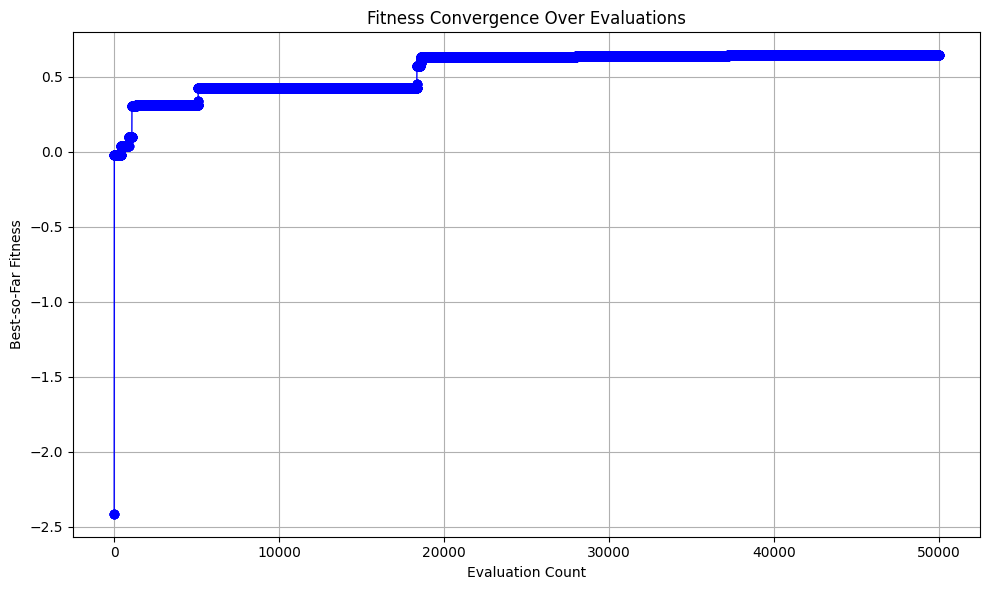

c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\pycgp_finalclass\Genome.py:243: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


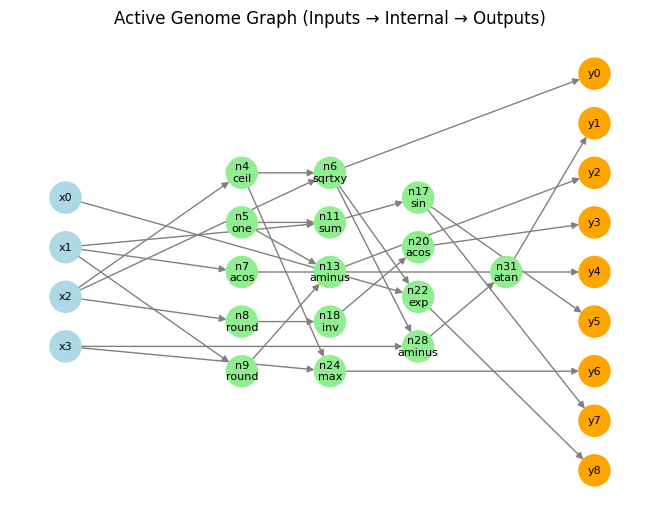

In [7]:
##WORK IN PROGRESS

from pmlb import fetch_data
from sklearn.preprocessing import MinMaxScaler

# Returns NumPy arrays
gametes = fetch_data('1027_ESL')
X, y = fetch_data('1027_ESL', return_X_y=True, local_cache_dir='./datasets')

# Conversion des colonnes en float
X = X.astype(float)
y = y.astype(float)

# Standardisation avec MinMaxScaler dans l'intervalle [-1, 1]
scaler = MinMaxScaler(feature_range=(-1, 1))
X = scaler.fit_transform(X)

evaluator2 = Regressor(X, y)

#Initialise config + Evaluator + mutation 
CGP_config = CGPConfig(num_inputs=X.shape[1], num_nodes=30, num_outputs=9, input_node_chance=0.4, const_min=-1, const_max=1, function_set=functions)
#For evaluatorsin num_inputs = 1

#mutationcgp_proba = Proba_Mutation(CGP_config, number_mutations=10, input_node_mutation_rate=0.2, output_node_mutation_rate=0.1, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1)
mutationcgp_golden = Golden_mutation(CGP_config,input_node_mutation_rate=0.2, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1,output_node_mutation_rate=0.5)
ES_cgp = ES(evaluator2, lam=5,parent = CGPGenome.create_genome(CGP_config),mutation = mutationcgp_golden)
best_genome = ES_cgp.evolve(n_generations=10000, early_stopping=10000, verbose=False)



In [8]:
# add unit test (create simple graph to see if the algorithm works) see from pycgp
# make the code clear and usable on github (notebook exemple)
# compare pycgp to other machine learning methods
# see later (distribution of inputs nodes for feature selection) make a test branch

In [11]:
from pmlb import fetch_data
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
import pandas as pd

# --- Load the dataset ---
X, y = fetch_data('1027_ESL', return_X_y=True, local_cache_dir='./datasets')

# --- Split the dataset ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Optional: Standardize features for models that benefit from it (SVM, KNN, Ridge, etc.) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Define regression models ---
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Support Vector Regressor': SVR(),
    'KNN Regressor': KNeighborsRegressor()
}

# --- Evaluate R² for each model ---
results = {}

for name, model in models.items():
    if name in ['Support Vector Regressor', 'KNN Regressor', 'Ridge Regression']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    results[name] = r2
    print(f"{name}: R² score = {r2:.4f}")

# --- Show sorted results ---
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['R2 Score'])
df_results = df_results.sort_values('R2 Score', ascending=False)
print("\n=== Sorted Results ===")
print(df_results)

print("\n=== CGP result ===")
print(f"CGP: R² score = {evaluator2.evaluate(best_genome)}")


Linear Regression: R² score = 0.8234
Ridge Regression: R² score = 0.8233
Random Forest: R² score = 0.7418
Gradient Boosting: R² score = 0.8038
Support Vector Regressor: R² score = 0.8075
KNN Regressor: R² score = 0.8001

=== Sorted Results ===
                          R2 Score
Linear Regression         0.823357
Ridge Regression          0.823297
Support Vector Regressor  0.807521
Gradient Boosting         0.803834
KNN Regressor             0.800066
Random Forest             0.741804

=== CGP result ===
CGP: R² score = 0.6429754255812412
